<a target="_blank" href="https://colab.research.google.com/github/cyneuro/ML_camp/blob/main/camp_logreg_microbit.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Mini-project 2A. Classification of accelerometer data using the micro:bit

By: Shokhsanam Uktamova and Caroline Lewis
CS 4001

Use this notebook to estimate a model for classifying whether the micro:bit is being held steady or being shaken. The notebook uses logistic regression as an example, but you are free to use any other model or create a rule-based classification system. Report the classification accuracy and give suggestions on how to improve it.

In [4]:
from google.colab import files
uploaded = files.upload()

Saving microbit_movement_data.csv to microbit_movement_data.csv


# Logistic regression with micro:bit

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## 1. Read and preprocess the data

- Read the recorded dataset.
- Compute velocity and position from acceleration.

In [6]:
import numpy as np
from scipy.integrate import cumulative_trapezoid

# Convert milligravities to m/s^2
MG_TO_MS2 = 0.00980665

def process_data(data):

    # Rename columns to something cleaner
    data = data.rename(columns={
        "timestamp": "t",
        "x": "ax",
        "y": "ay",
        "z": "az"
    })

    # Keep only needed columns (including label)
    data = data[["t", "ax", "ay", "az", "label"]]

    # Drop missing values
    data = data.dropna()

    # Convert acceleration from mg to m/s^2
    for acc in ["ax", "ay", "az"]:
        data[acc] = data[acc] * MG_TO_MS2

    # Replace extreme outliers using median rule
    for acc in ["ax", "ay", "az"]:
        median = np.median(data[acc])
        data.loc[np.abs(data[acc] / median) > 3, acc] = median

    # Compute acceleration magnitude (VERY useful feature)
    data["a_mag"] = np.sqrt(
        data["ax"]**2 +
        data["ay"]**2 +
        data["az"]**2
    )

    return data

In [7]:
data = pd.read_csv("/content/microbit_movement_data.csv")
data = process_data(data)
data.head()

,t,ax,ay,az,label,a_mag
0,0.00,-2.216303,3.216581,-1.922103,0,4.353490
1,0.11,-2.216303,3.216581,-2.157463,0,4.462403
2,0.21,-2.216303,3.177355,-1.843650,0,4.290294
3,0.32,-2.216303,3.177355,-1.922103,0,4.324588
4,0.42,-2.216303,-1.078731,-2.079010,0,3.224584


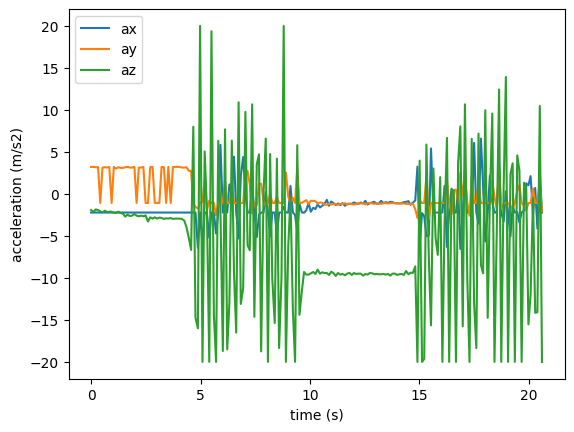

In [8]:
for acc in ['ax', 'ay', 'az']:
    plt.plot(data['t'], data[acc], label = acc)
plt.xlabel("time (s)")
plt.ylabel("acceleration (m/s2)")
plt.legend()

## 2. Split into train and test samples.
- Train: the first shake.
- Test: the second shake.

In [10]:
# Training on first half
train_rest = (0.0, 5.0)
train_shake = (5.0, 10.0)

# Testing on second half
test_rest = (10.0, 15.0)
test_shake = (15.0, 20.6)

In [11]:
def construct_Xy(data, window_rest, window_shake):
    X = pd.concat((
        data.loc[(data['t'] >= window_rest[0]) & (data['t'] <= window_rest[1]), ['t', 'ax', 'ay', 'az']],
        data.loc[(data['t'] >= window_shake[0]) & (data['t'] <= window_shake[1]), ['t', 'ax', 'ay', 'az']],
    ))
    y = np.ones(len(X))
    y[(X['t'] >= window_rest[0]) & (X['t'] <= window_rest[1])] = 0

    return X, y

In [12]:
X_train, y_train = construct_Xy(data, train_rest, train_shake)
X_test, y_test = construct_Xy(data, test_rest, test_shake)

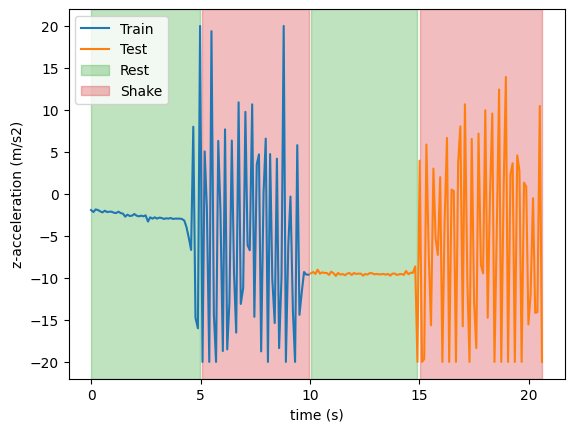

In [13]:
plt.plot(X_train['t'], X_train["az"], label = "Train")
plt.plot(X_test['t'], X_test["az"], label = "Test")

label_set = False
for X, y in [(X_train, y_train), (X_test, y_test)]:
    for y_value, y_label in enumerate(["Rest", "Shake"]):
        plt.axvspan(
            X['t'].to_numpy()[np.where(y == y_value)[0][0]],
            X['t'].to_numpy()[np.where(y == y_value)[0][-1]],
            alpha = 0.3,
            color = "tab:green" if y_value == 0 else "tab:red",
            label = y_label if not label_set else None
            )
    label_set = True

plt.xlabel("time (s)")
plt.ylabel("z-acceleration (m/s2)")
plt.legend()

## 3. Train a logistic regression model

Compare 2 models.

**Model 1.**

$$
\hat{p} = \sigma(b_0 + b_t \times t + b_x \times a_x + b_y \times a_y + b_z \times a_z)
$$

**Model 2.**

$$
\hat{p} = \sigma(b_0 + b_x \times a_x + b_y \times a_y + b_z \times a_z)
$$

In [14]:
model1 = LogisticRegression()
model1.fit(X_train[["t", "ax", "ay", "az"]], y_train)

model2 = LogisticRegression()
model2.fit(X_train[["ax", "ay", "az"]], y_train)

LogisticRegression()

In [15]:
print("ACCURACY")
print("--------")
print("Model\tTrain\tTest")
for model_id, (model, features) in enumerate((
    (model1, ["t", "ax", "ay", "az"]),
    (model2, ["ax", "ay", "az"])
    )):
    train_acc = round(accuracy_score(y_train, model.predict(X_train[features])), 2)
    test_acc = round(accuracy_score(y_test, model.predict(X_test[features])), 2)
    print(f"M{model_id}\t{train_acc}\t{test_acc}")

ACCURACY
--------
Model	Train	Test
M0	0.98	0.53
M1	0.74	0.4


In [16]:
model1.predict(X_test[["t", "ax", "ay", "az"]])

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1.])

In [17]:
model2.predict(X_test[["ax", "ay", "az"]])

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1.,
       0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
       1.])

### Question

Explain the observed difference between predictions of the two models.

**Hint: compare the decision lines.**

In [18]:
print(f"Model1: intercept = {model1.intercept_}, coef = {model1.coef_}")
print(f"Model2: intercept = {model2.intercept_}, coef = {model2.coef_}")

Model1: intercept = [-11.38197157], coef = [[ 2.30908918  0.12668064 -0.25825134 -0.02472416]]
Model2: intercept = [0.73519135], coef = [[ 0.20604455 -0.63938677 -0.0290368 ]]


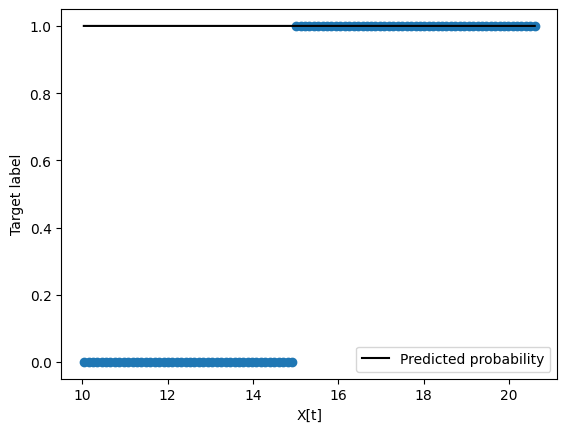

In [19]:
plt.scatter(X_test["t"], y_test)
plt.xlabel("X[t]")
plt.ylabel("Target label")

plt.plot(X_test["t"], model1.predict_proba(X_test[["t", "ax", "ay", "az"]])[:, 1], label = "Predicted probability", c = "black")
plt.legend()

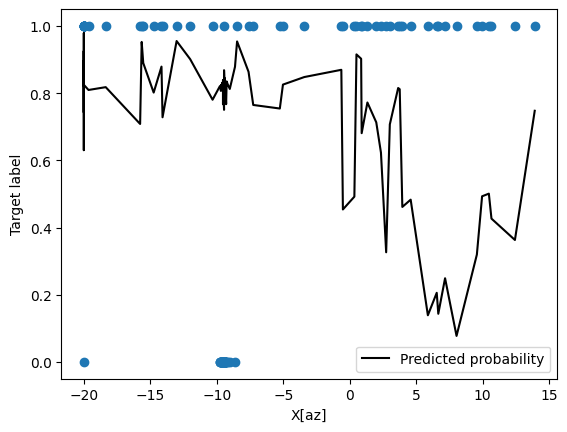

In [20]:
plt.scatter(X_test["az"], y_test)
plt.xlabel("X[az]")
plt.ylabel("Target label")

plt.plot(X_test.sort_values("az")["az"], model2.predict_proba(X_test.sort_values("az")[["ax", "ay", "az"]])[:, 1], label = "Predicted probability", c = "black")
plt.legend()

### Classification Accuracy

### Results
Two logistic regression models were evaluated.

The first model "M0" used the following features:
- t, ax, ay, and az
Its accuracy was as follows:
- Train: 0.98
- Test: 0.53

The second model "M1" used the following features:
- ax, ay, and az
Its accuracy was as follows:
- Train: 0.74
- Test: 0.40

### What this means:
#### Model 0
 It did well on training (98%) but guessed randomly essentially for testing (53% accuracy) because it used the timestamp column. It learned that if the time is between X and Y it must be steady because we had 0-5 seconds steady, so it failed when tested on a new time range. Essentially the model was overfitting the data. The timestamp was used over the physical characteristics of motion.

#### Model 1
It got 74% training accuracy and 40% test accuracy. This indicates that the raw axis values alone are not sufficient to distinguish steady from shaking.

### Suggestions on how to improve it:
- We could improve the classification performance by using better feature engineering. Instead of using raw axis values, derived features such as acceleration magnitude could be used. We could also do the following
- use rolling mean and rolling standard deviation to help capture motion variability over short time windows
- collect more training data
- normalize the features before training

All of these things could improve the accuracy of our models in classifying shake or steady.